In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader, TensorDataset
import os
import time
import warnings
from tqdm import tqdm  # 用于显示进度条
import optuna
TRAIN_DAY=144

In [ ]:
# 忽略警告
warnings.filterwarnings('ignore')

# 配置参数
class Config:
    SEQ_LEN = 14 * 96  # 输入序列长度：14天数据
    PRED_LEN = 4      # 预测长度：1天数据 (96个时间点)
    TEST_START_DAY = 15  # 开始测试的第几天
    TEST_END_DAY = 28    # 结束测试的第几天

    # LSTM模型参数
    HIDDEN_SIZE = 128
    NUM_LAYERS = 2
    DROPOUT = 0.228
    
    # 训练参数
    BATCH_SIZE = 128
    LEARNING_RATE = 0.0008
    NUM_EPOCHS = 20  # 从 100 减少到 10 以便快速测试。如果需要完整训练，可以再增加。
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    PRINT_EVERY = 1  # 每个epoch都打印进度

# 自定义数据集类
class ElectricityPriceDataset(Dataset):
    def __init__(self, prices, seq_len, pred_len):
        self.prices = prices
        self.seq_len = seq_len
        self.pred_len = pred_len
        
        # 创建输入序列和目标序列
        self.X, self.y = self.create_sequences()
    
    def create_sequences(self):
        X, y = [], []
        total_points = len(self.prices)
        
        # 为每个可能的序列创建输入和目标
        if total_points < self.seq_len + self.pred_len:
            return np.array([]), np.array([])
        
        for i in range(total_points - self.seq_len - self.pred_len + 1):
            X.append(self.prices[i:i+self.seq_len])
            y.append(self.prices[i+self.seq_len:i+self.seq_len+self.pred_len])
        
        return np.array(X), np.array(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.FloatTensor(self.y[idx])

# LSTM预测模型
class PricePredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=Config.HIDDEN_SIZE, 
                 num_layers=Config.NUM_LAYERS, output_size=Config.PRED_LEN, 
                 dropout=Config.DROPOUT):
        super(PricePredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM层
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        # 初始化隐藏状态
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(Config.DEVICE)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(Config.DEVICE)
        
        # 检查输入维度并调整为3D
        if x.dim() == 2:
            # 如果输入是2D (批次大小, 序列长度)，添加特征维度
            x = x.unsqueeze(-1)  # 变为 (批次大小, 序列长度, 1)
        elif x.dim() == 3:
            # 如果输入已经是3D，保持不变
            pass
        else:
            raise ValueError(f"输入维度 {x.dim()} 不支持，应为2D或3D")
        
        # LSTM前向传播
        out, _ = self.lstm(x, (h0, c0))
        
        # 只取最后一个时间步的输出
        out = out[:, -1, :]
        
        # 全连接层生成预测
        return self.fc(out)

In [17]:
# --- 1. 加载和准备数据 ---
print(f"使用设备: {Config.DEVICE}")
if Config.DEVICE.type == 'cpu':
    print("警告: 未检测到CUDA GPU。在CPU上训练可能会非常慢。")

# 加载训练数据
print("\n加载训练数据...")
train_data_path = os.path.join('..', 'data', 'train_prices.csv')
train_df = pd.read_csv(train_data_path)
price_column = train_df.columns[-1]
train_prices_full = train_df[price_column].values.astype(float).reshape(-1, 1)

# --- 修改：只使用前30天的数据进行训练 ---
days_to_use = TRAIN_DAY
points_per_day = 96 # 每天有96个数据点 (24小时 * 4个点/小时)
train_prices = train_prices_full[:days_to_use * points_per_day]
# -----------------------------------------

print(f"训练数据加载成功，共 {len(train_prices)} 个点。")

# 数据预处理 - 使用训练数据拟合归一化scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_prices = scaler.fit_transform(train_prices)

# 加载测试数据
print("\n加载测试数据...")
test_data_path = os.path.join('..', 'data', 'test_prices.csv')
test_df = pd.read_csv(test_data_path)
test_prices = test_df[price_column].values.astype(float).reshape(-1, 1)
scaled_test_prices = scaler.transform(test_prices)
print(f"测试数据加载成功，共 {len(test_prices)} 个点。")

# 创建数据集和数据加载器
train_dataset = ElectricityPriceDataset(
    scaled_train_prices.flatten(), Config.SEQ_LEN, Config.PRED_LEN
)
if len(train_dataset) == 0:
    raise ValueError("错误: 训练数据集为空！请检查数据长度和SEQ_LEN/PRED_LEN设置。")

train_loader = DataLoader(
    train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True
)
print(f"\n创建了 {len(train_dataset)} 个训练样本。")

使用设备: cuda

加载训练数据...
训练数据加载成功，共 13824 个点。

加载测试数据...
测试数据加载成功，共 15456 个点。

创建了 12469 个训练样本。


In [18]:
# --- 2. 训练模型 ---
# 初始化模型、损失函数和优化器
model = PricePredictor().to(Config.DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

print("\n开始训练模型...")
train_losses = []
start_time = time.time()

progress_bar = tqdm(range(Config.NUM_EPOCHS), desc="训练进度", unit="epoch")

for epoch in progress_bar:
    model.train()
    epoch_loss = 0
    
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.NUM_EPOCHS}", leave=False)
    
    for inputs, targets in batch_bar:
        inputs, targets = inputs.to(Config.DEVICE), targets.to(Config.DEVICE)
        
        # 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.6f}")
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    progress_bar.set_postfix(epoch_loss=f"{avg_loss:.6f}")

training_time = time.time() - start_time
print(f"\n模型训练完成! 总耗时: {training_time:.1f}秒")


开始训练模型...


训练进度: 100%|██████████| 20/20 [02:39<00:00,  7.98s/epoch, epoch_loss=0.002016]


模型训练完成! 总耗时: 159.6秒


In [19]:
# --- 3. 测试模型 ---
# 确定要预测的总天数
total_test_days_available = len(test_prices) // 96
start_day_idx = Config.TEST_START_DAY - 1
end_day_idx = min(Config.TEST_END_DAY, total_test_days_available)

print(f"\n开始滚动预测从第 {Config.TEST_START_DAY} 天到第 {end_day_idx} 天的测试数据...")
model.eval()

all_predictions = []
all_actuals = []

# 初始化预测起始点（使用训练数据的最后部分）
initial_input_data = scaled_train_prices[-Config.SEQ_LEN:]
current_input_for_day = initial_input_data.flatten()

# 循环预测指定范围的每一天
for day_idx in range(start_day_idx, end_day_idx):
    day_progress_desc = f"预测第 {day_idx + 1} 天"
    
    daily_predictions = []
    daily_actuals = []
    
    # 将当天的输入序列复制一份，用于本天的滚动预测
    rolling_input = np.copy(current_input_for_day)
    
    # 一天需要预测 96 / 12 = 8 次
    num_segments = 96 // Config.PRED_LEN
    
    for i in range(num_segments):
        # 准备输入序列
        input_seq = torch.FloatTensor(rolling_input).unsqueeze(0).to(Config.DEVICE)
        
        # 使用模型进行预测
        with torch.no_grad():
            pred = model(input_seq)
        
        # 反归一化预测结果
        pred_scaled = pred.cpu().numpy().flatten()
        pred_original = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        daily_predictions.extend(pred_original)
        
        # 获取这12个点的真实数据，用于更新输入序列
        actual_start_idx = day_idx * 96 + i * Config.PRED_LEN
        actual_end_idx = actual_start_idx + Config.PRED_LEN
        
        if actual_end_idx > len(test_prices):
            print(f"警告: 测试数据不足以完成第 {day_idx + 1} 天的滚动预测，测试提前结束。")
            break
            
        actual_original_segment = test_prices[actual_start_idx:actual_end_idx].flatten()
        daily_actuals.extend(actual_original_segment)
        
        # 使用真实数据（归一化后）来滚动更新输入序列
        actual_scaled_segment = scaled_test_prices[actual_start_idx:actual_end_idx].flatten()
        rolling_input = np.concatenate([rolling_input[Config.PRED_LEN:], actual_scaled_segment])

    if len(daily_predictions) == 96:
        all_predictions.append(daily_predictions)
        all_actuals.append(daily_actuals)
        print(f"{day_progress_desc} 完成。")
    else:
        # 如果一天没有被完整预测，则跳过
        break

    # 更新下一天的起始输入序列
    # 使用当天完整的真实数据来更新，确保第二天预测的起点是准确的
    day_actual_start = day_idx * 96
    day_actual_end = day_actual_start + 96
    full_day_actual_scaled = scaled_test_prices[day_actual_start:day_actual_end].flatten()
    current_input_for_day = np.concatenate([current_input_for_day[96:], full_day_actual_scaled])


print("\n模型测试完成。")


开始滚动预测从第 15 天到第 28 天的测试数据...
预测第 15 天 完成。
预测第 16 天 完成。
预测第 17 天 完成。
预测第 18 天 完成。


预测第 19 天 完成。
预测第 20 天 完成。
预测第 21 天 完成。
预测第 22 天 完成。
预测第 23 天 完成。
预测第 24 天 完成。
预测第 25 天 完成。
预测第 26 天 完成。
预测第 27 天 完成。
预测第 28 天 完成。

模型测试完成。



预测结果评估:
总RMSE: 6.0595
总MAE: 4.2767
与平均电价相比的相对RMSE: 15.17%


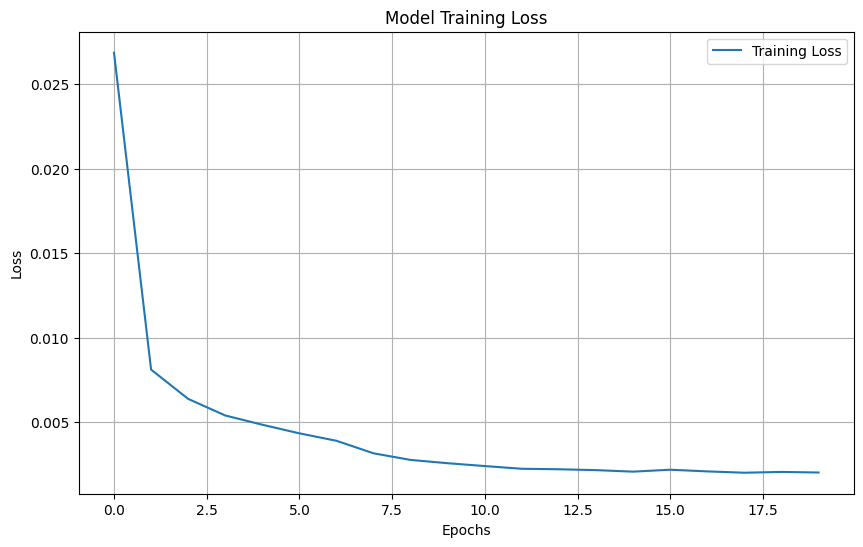

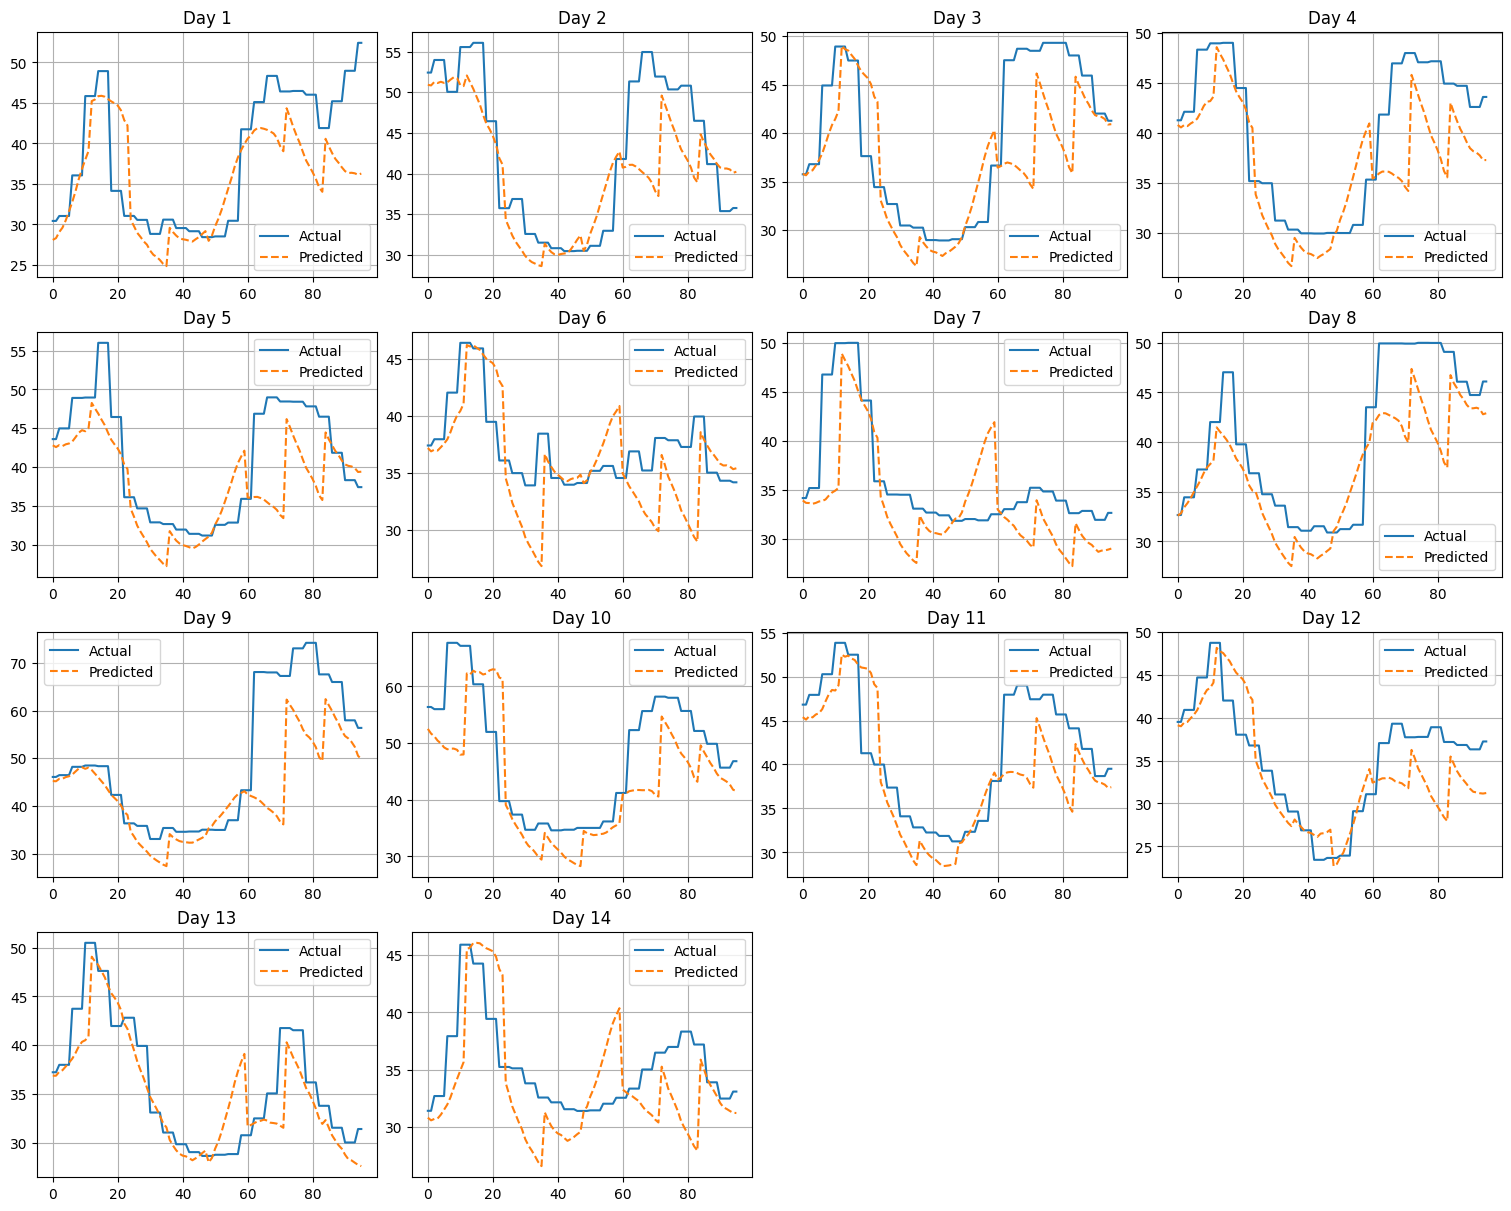

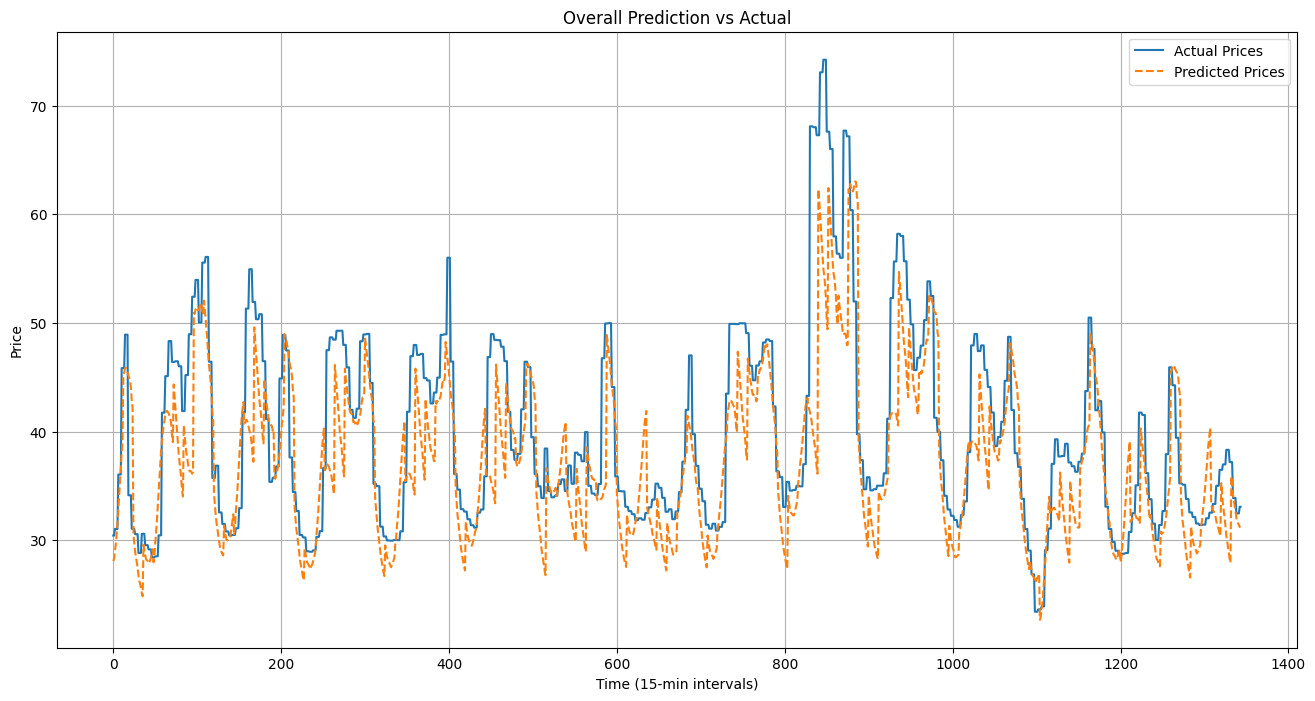


预测结果已保存到 prediction_results.csv
可视化结果已保存为图像文件。


In [20]:
# --- 4. 评估、可视化和保存 ---
flat_predictions = [p for day_predictions in all_predictions for p in day_predictions]
flat_actuals = [a for day_actuals in all_actuals for a in day_actuals]

# 计算评估指标
rmse = np.sqrt(mean_squared_error(flat_actuals, flat_predictions))
mae = mean_absolute_error(flat_actuals, flat_predictions)
mean_price = np.mean(flat_actuals)
relative_rmse = rmse / mean_price * 100 if mean_price != 0 else 0

print("\n预测结果评估:")
print(f"总RMSE: {rmse:.4f}")
print(f"总MAE: {mae:.4f}")
print(f"与平均电价相比的相对RMSE: {relative_rmse:.2f}%")

# 绘制训练损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.title('Model Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('training_loss.png', dpi=300)
plt.show()

# 绘制每日预测对比图
num_days = len(all_predictions)
if num_days > 0:
    cols = 4
    rows = (num_days + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), constrained_layout=True)
    axes = axes.flatten()
    for i in range(num_days):
        axes[i].plot(all_actuals[i], label='Actual')
        axes[i].plot(all_predictions[i], label='Predicted', linestyle='--')
        axes[i].set_title(f'Day {i+1}')
        axes[i].grid(True)
        axes[i].legend()
    # 隐藏多余的子图
    for i in range(num_days, len(axes)):
        fig.delaxes(axes[i])
    plt.savefig('daily_predictions.png', dpi=300)
    plt.show()

# 绘制综合对比图
plt.figure(figsize=(16, 8))
plt.plot(flat_actuals, label='Actual Prices')
plt.plot(flat_predictions, label='Predicted Prices', linestyle='--')
plt.title('Overall Prediction vs Actual')
plt.xlabel('Time (15-min intervals)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.savefig('overall_prediction_comparison.png', dpi=300)
plt.show()

# 保存结果到CSV
results = []
for i in range(len(all_predictions)):
    for j in range(len(all_predictions[i])):
        hour = j // 4
        minute = (j % 4) * 15
        time_str = f"{hour:02d}:{minute:02d}"
        results.append({
            'Day': i + 1,
            'Time': time_str,
            'Actual': all_actuals[i][j],
            'Predicted': all_predictions[i][j]
        })
results_df = pd.DataFrame(results)
results_df.to_csv('prediction_results.csv', index=False)

print("\n预测结果已保存到 prediction_results.csv")
print("可视化结果已保存为图像文件。")

In [21]:
def objective(trial, all_train_data, scaler):
    """Optuna的目标函数，用于评估一组超参数的性能"""
    
    # 1. 定义要优化的超参数搜索空间
    params = {
        'hidden_size': trial.suggest_categorical('hidden_size', [128, 256, 512]),
        'num_layers': trial.suggest_int('num_layers', 2, 5),
        'dropout': trial.suggest_float('dropout', 0.1, 0.5),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [64, 128])
    }
    
    # 为了进行稳健的调优，我们将传入的训练数据再次划分为训练集和验证集
    # 例如，使用前12天数据进行训练，后2天数据进行验证
    val_split_point = 12 * 96
    train_subset_data = all_train_data[:val_split_point]
    val_subset_data = all_train_data[val_split_point:]

    # 创建数据集和加载器
    train_dataset = ElectricityPriceDataset(train_subset_data.flatten(), Config.SEQ_LEN, Config.PRED_LEN)
    val_dataset = ElectricityPriceDataset(val_subset_data.flatten(), Config.SEQ_LEN, Config.PRED_LEN)
    
    # 如果验证集太小，无法创建样本，则返回一个很大的值，让Optuna放弃此分支
    if len(val_dataset) == 0:
        return float('inf')

    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=params['batch_size'])

    # 2. 使用建议的参数初始化模型
    model = PricePredictor(
        hidden_size=params['hidden_size'],
        num_layers=params['num_layers'],
        dropout=params['dropout']
    ).to(Config.DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'])
    
    # 3. 训练模型（使用较少的轮数以加快调优速度）
    num_epochs_tuning = 15  # 在调优时，每个试验不需要跑太多轮
    for epoch in range(num_epochs_tuning):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(Config.DEVICE), targets.to(Config.DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

    # 4. 在验证集上评估模型
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(Config.DEVICE), targets.to(Config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    # 5. 返回要最小化的指标（这里是验证集上的MSE）
    return avg_val_loss

def run_hyperparameter_tuning():
    """主函数，用于执行超参数搜索"""
    print("开始超参数调优...")
    
    # --- 复用main函数的数据加载和预处理部分 ---
    data_path = os.path.join('..', 'data', 'test_prices.csv')
    if not os.path.exists(data_path):
        print(f"错误: 文件不存在 - {data_path}")
        return
    
    data = pd.read_csv(data_path)
    price_column = data.columns[-1]
    prices = data[price_column].values.astype(float).reshape(-1, 1)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_prices = scaler.fit_transform(prices)
    
    # 训练集：前14天的数据 (用于在objective函数中进一步划分为训练/验证)
    train_data = scaled_prices[:14 * 96]
    
    # --- Optuna 设置 ---
    # 创建一个研究，目标是最小化 objective 函数的返回值
    study = optuna.create_study(direction='minimize')
    
    # 开始优化，n_trials 是要运行的试验次数
    # 增加试验次数会得到更好的结果，但需要更长时间
    study.optimize(lambda trial: objective(trial, train_data, scaler), n_trials=50)
    
    # --- 输出结果 ---
    print("\n调优完成!")
    print(f"总试验次数: {len(study.trials)}")
    
    best_trial = study.best_trial
    print("最佳试验:")
    print(f"  - 评估指标 (MSE): {best_trial.value:.6f}")
    print("  - 最佳参数:")
    for key, value in best_trial.params.items():
        print(f"    - {key}: {value}")

    # 可视化结果
    try:
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()
        fig = optuna.visualization.plot_param_importances(study)
        fig.show()
    except Exception as e:
        print(f"无法生成可视化图像: {e}")


# 运行调优过程
if __name__ == "__main__":
    # 你可以选择运行原始的main函数或新的调优函数
    # main() 
    run_hyperparameter_tuning()

[I 2025-07-30 22:54:48,334] A new study created in memory with name: no-name-f74fde92-db80-4181-b7bf-de655b93bf09
[I 2025-07-30 22:54:48,335] Trial 0 finished with value: inf and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.22795394470329172, 'learning_rate': 0.000810446949018371, 'batch_size': 128}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,335] Trial 1 finished with value: inf and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.11588472027899877, 'learning_rate': 0.0006938402747530326, 'batch_size': 64}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,336] Trial 2 finished with value: inf and parameters: {'hidden_size': 512, 'num_layers': 5, 'dropout': 0.14759403345117383, 'learning_rate': 0.0005583617510835169, 'batch_size': 64}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,337] Trial 3 finished with value: inf and parameters: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.1968260730661, 'learning_rate': 0.0001149

开始超参数调优...


[I 2025-07-30 22:54:48,497] Trial 28 finished with value: inf and parameters: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.27101060974637814, 'learning_rate': 0.0004194770957352919, 'batch_size': 128}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,505] Trial 29 finished with value: inf and parameters: {'hidden_size': 512, 'num_layers': 3, 'dropout': 0.1876388549156207, 'learning_rate': 0.00017025453676385155, 'batch_size': 64}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,514] Trial 30 finished with value: inf and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.21531163267269796, 'learning_rate': 0.0006184262578211649, 'batch_size': 64}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,522] Trial 31 finished with value: inf and parameters: {'hidden_size': 256, 'num_layers': 3, 'dropout': 0.16608776104757852, 'learning_rate': 0.00024418839075860934, 'batch_size': 64}. Best is trial 0 with value: inf.
[I 2025-07-30 22:54:48,531] Trial 32 f


调优完成!
总试验次数: 50
最佳试验:
  - 评估指标 (MSE): inf
  - 最佳参数:
    - hidden_size: 128
    - num_layers: 2
    - dropout: 0.22795394470329172
    - learning_rate: 0.000810446949018371
    - batch_size: 128
无法生成可视化图像: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.
